<a href="https://colab.research.google.com/github/umraodeepika7-dotcom/ctgan/blob/main/SDV_Synthesize_a_table_(CTGAN).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[SDV Docs](https://docs.sdv.dev/sdv) > [Tutorials](https://docs.sdv.dev/sdv/tutorials)

# Synthesize a Table (CTGAN)

In this notebook, we'll use the SDV to create synthetic data for a single table and evaluate it. The SDV uses machine learning to learn patterns from real data and emulates them when creating synthetic data.

We'll use the **CTGAN** algorithm to do this. CTGAN uses generative adversarial networks (GANs) to create synthesize data with high fidelity.

_Last Edit: January 30, 2026_

# 0. Installation

Install SDV Community.

In [2]:
%pip install sdv

In [1]:
!pip install table_evaluator

In [1]:
!pip install dython

# 1. Loading the real data
For this demo,  use a real dataset that describes four acid pretreatment methods for rice straw and their impact on total reducing sugars, cellubiose, inhibitor, etc

In [3]:
from google.colab import files
uploaded = files.upload()

Saving RS pretreatment.csv to RS pretreatment.csv


In [4]:
import pandas as pd
data = pd.read_csv('RS pretreatment.csv')

In [5]:
real_data = pd.read_csv('RS pretreatment.csv')

In [6]:
from sdv.metadata import SingleTableMetadata

metadata = SingleTableMetadata()
metadata.detect_from_dataframe(data=real_data)

In [52]:
display(real_data.head(8))

,Catalyst,samples,Xylose,Glucose,Arabinose,Cellubiose,Total RS,Furfural,Acetate,COD
0,H2O,Original,0.60,0.61,1.00,1.25,3.17,0.00,0.88,31.67
1,H2O,Treated,0.68,0.58,0.94,1.07,2.66,0.00,0.92,22.24
2,H2SO4,Original,10.81,2.55,3.81,1.63,36.70,2.49,7.65,69.84
3,H2SO4,Treated,10.70,1.89,4.09,1.72,31.10,0.00,1.31,44.40
4,HCl,Original,37.26,0.66,5.97,11.18,66.37,4.55,5.46,74.64
5,HCl,Treated,34.86,0.33,5.29,11.02,60.00,0.00,0.27,65.28
6,HNO3,Original,30.22,2.29,6.95,9.65,63.40,1.37,3.25,83.90
7,HNO3,Treated,31.22,2.06,6.23,10.82,61.60,0.00,3.05,64.50


In [8]:
categorical_features = ['Catalyst', 'samples']

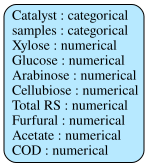

In [9]:
metadata.visualize()

In [10]:
from sdv.single_table import CTGANSynthesizer

synthesizer = CTGANSynthesizer(
    metadata, # required
    enforce_min_max_values=True,
    epochs=500,
    verbose=True
)

/usr/local/lib/python3.12/dist-packages/sdv/single_table/base.py:178: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
/usr/local/lib/python3.12/dist-packages/sdv/single_table/base.py:134: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(


# 2. Basic Usage

## 2.1 Creating a Synthesizer

An SDV **synthesizer** is an object that you can use to create synthetic data. It learns patterns from the real data and replicates them to generate synthetic data.

In [11]:
from sdv.single_table import GaussianCopulaSynthesizer

# Initialize the GaussianCopulaSynthesizer
gmm_synthesizer = GaussianCopulaSynthesizer(metadata)

# Fit the synthesizer to the real data
gmm_synthesizer.fit(real_data)

## 2.2 Generating Synthetic Data
Use the `sample` function and pass in any number of rows to synthesize.

In [12]:
from sdv.single_table import GaussianCopulaSynthesizer

# Initialize the GaussianCopulaSynthesizer
gmm_synthesizer = GaussianCopulaSynthesizer(metadata)

# Fit the synthesizer to the real data
gmm_synthesizer.fit(real_data)

/usr/local/lib/python3.12/dist-packages/sdv/single_table/base.py:178: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)


In [13]:

# Generate synthetic data using the GMM synthesizer
synthetic_data_from_gmm = gmm_synthesizer.sample(len(real_data) * 50)

print(f"Generated {len(synthetic_data_from_gmm)} synthetic rows using GMM.")
display(synthetic_data_from_gmm.head())

Generated 400 synthetic rows using GMM.


,Catalyst,samples,Xylose,Glucose,Arabinose,Cellubiose,Total RS,Furfural,Acetate,COD
0,HCl,Original,23.46,2.49,6.93,7.63,65.38,2.13,7.25,83.62
1,H2SO4,Original,10.43,2.55,6.64,3.12,36.32,2.87,7.63,81.35
2,HCl,Treated,16.16,2.23,2.22,5.61,53.12,0.02,7.41,37.33
3,H2O,Treated,3.34,0.48,3.80,2.69,12.81,0.00,3.46,62.58
4,HNO3,Treated,31.61,0.35,5.83,8.58,57.92,0.00,0.50,56.62


### Enforcing Group-wise Min/Max Values
To ensure that the synthetic data adheres to the min/max values observed for each `Catalyst` in the real data, we need to perform a post-processing step. First, we'll calculate the min and max for each numerical column, grouped by `Catalyst`, from the `real_data`. Then, we'll apply these bounds to the `synthetic_data`.

In [49]:
numeric_cols = ['Xylose', 'Glucose', 'Arabinose', 'Cellubiose', 'Total RS', 'Furfural', 'Acetate', 'COD']

# Calculate group-wise min/max from real_data
group_min_max = real_data.groupby('Catalyst')[numeric_cols].agg(['min', 'max'])

# Define a function to enforce group-wise min/max
def enforce_group_min_max_for_row(row, group_min_max_df, group_col, numeric_columns):
    catalyst_group = row[group_col]
    if catalyst_group in group_min_max_df.index:
        for col in numeric_columns:
            min_val = group_min_max_df.loc[catalyst_group, (col, 'min')]
            max_val = group_min_max_df.loc[catalyst_group, (col, 'max')]
            row[col] = max(min_val, min(max_val, row[col]))
    return row

# Create a copy to store the enforced synthetic data
synthetic_data_enforced = synthetic_data_from_gmm.copy()

# Apply the enforcement function to each row of the synthetic data
synthetic_data_enforced = synthetic_data_enforced.apply(lambda row: enforce_group_min_max_for_row(row, group_min_max, 'Catalyst', numeric_cols), axis=1)

print("Synthetic data after enforcing group-wise min/max values:")
display(synthetic_data_enforced.head(400))

Synthetic data after enforcing group-wise min/max values:


,Catalyst,samples,Xylose,Glucose,Arabinose,Cellubiose,Total RS,Furfural,Acetate,COD
0,HCl,Original,34.86,0.66,5.97,11.02,65.38,2.13,5.46,74.64
1,H2SO4,Original,10.70,2.55,4.09,1.72,36.32,2.49,7.63,69.84
2,HCl,Treated,34.86,0.66,5.29,11.02,60.00,0.02,5.46,65.28
3,H2O,Treated,0.68,0.58,1.00,1.25,3.17,0.00,0.92,31.67
4,HNO3,Treated,31.22,2.06,6.23,9.65,61.60,0.00,3.05,64.50
...,...,...,...,...,...,...,...,...,...,...
395,H2SO4,Original,10.81,2.50,4.09,1.72,31.10,1.24,6.87,63.39
396,HCl,Treated,34.86,0.66,5.97,11.02,65.48,1.16,5.46,74.64
397,H2O,Treated,0.68,0.58,1.00,1.25,3.17,0.00,0.88,24.02
398,HNO3,Treated,31.22,2.06,6.63,10.82,63.40,0.01,3.05,73.39


In [56]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
display(synthetic_data_enforced)

,Catalyst,samples,Xylose,Glucose,Arabinose,Cellubiose,Total RS,Furfural,Acetate,COD
0,HCl,Original,34.86,0.66,5.97,11.02,65.38,2.13,5.46,74.64
1,H2SO4,Original,10.70,2.55,4.09,1.72,36.32,2.49,7.63,69.84
2,HCl,Treated,34.86,0.66,5.29,11.02,60.00,0.02,5.46,65.28
3,H2O,Treated,0.68,0.58,1.00,1.25,3.17,0.00,0.92,31.67
4,HNO3,Treated,31.22,2.06,6.23,9.65,61.60,0.00,3.05,64.50
5,HCl,Original,34.86,0.40,5.97,11.02,60.00,0.90,1.98,74.11
6,H2O,Original,0.68,0.61,1.00,1.25,3.17,0.00,0.92,31.67
7,HCl,Treated,34.86,0.66,5.29,11.02,60.00,0.00,1.93,65.28
8,H2SO4,Original,10.81,1.89,4.09,1.72,36.70,2.49,4.32,69.84
9,H2O,Treated,0.68,0.61,1.00,1.25,3.17,0.00,0.92,31.67


In [18]:
synthesizer.fit(real_data)
synthetic_data = synthetic_data_enforced.sample(n=400, replace=True)
synthetic_data.head()

Gen. (-00.61) | Discrim. (-00.03): 100%|██████████| 500/500 [00:35<00:00, 14.14it/s]


,Catalyst,samples,Xylose,Glucose,Arabinose,Cellubiose,Total RS,Furfural,Acetate,COD
136,HNO3,Original,30.22,2.29,6.23,9.65,61.60,0.00,3.25,64.50
81,H2SO4,Original,10.81,1.89,4.09,1.72,36.70,2.49,2.88,69.84
91,H2O,Treated,0.68,0.61,1.00,1.25,3.17,0.00,0.92,31.67
187,H2SO4,Treated,10.70,1.89,3.81,1.72,31.10,0.00,1.31,44.40
87,HCl,Treated,34.86,0.36,5.29,11.02,62.87,0.00,1.82,65.28


### Comparing Distributions of Real vs. Enforced Synthetic Data

Now, let's visualize the 1D distributions of each numerical column to compare the `real_data` with the `synthetic_data_enforced` after applying group-wise min/max constraints.

In [22]:
# Install kaleido for plotly image export
%pip install kaleido

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 kB 2.9 MB/s eta 0:00:00


The synthesizer is generating synthetic guests in the **same format as the original data**.

### Quality Report Summary
Let's summarize the overall quality score from the previously generated report and also look into the details of 'Column Pair Trends'.

In [23]:
from sdv.evaluation.single_table import evaluate_quality

quality_report = evaluate_quality(
    real_data,
    synthetic_data_enforced,
    metadata
)
print(f"Overall Quality Score (Average): {quality_report.get_score():.2f}%")
quality_report.get_details('Column Pair Trends')

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 10/10 [00:00<00:00, 282.52it/s]|
Column Shapes Score: 86.6%

(2/2) Evaluating Column Pair Trends: |██████████| 45/45 [00:00<00:00, 93.06it/s]|
Column Pair Trends Score: 82.4%

Overall Score (Average): 84.5%

Overall Quality Score (Average): 0.85%


,Column 1,Column 2,Metric,Score,Real Correlation,Synthetic Correlation,Real Association,Meets Threshold?
0,Catalyst,samples,ContingencySimilarity,NaN,NaN,NaN,0.000000,False
1,Catalyst,Xylose,ContingencySimilarity,0.822500,NaN,NaN,1.000000,True
2,Catalyst,Glucose,ContingencySimilarity,0.785000,NaN,NaN,0.781736,True
3,Catalyst,Arabinose,ContingencySimilarity,0.817500,NaN,NaN,0.912871,True
4,Catalyst,Cellubiose,ContingencySimilarity,0.762500,NaN,NaN,0.707107,True
5,Catalyst,Total RS,ContingencySimilarity,0.800000,NaN,NaN,0.881917,True
6,Catalyst,Furfural,ContingencySimilarity,0.730000,NaN,NaN,0.632456,True
7,Catalyst,Acetate,ContingencySimilarity,0.462500,NaN,NaN,0.881917,True
8,Catalyst,COD,ContingencySimilarity,0.712500,NaN,NaN,0.912871,True
9,samples,Xylose,ContingencySimilarity,0.767500,NaN,NaN,0.500000,True


## 2.3 Evaluating Real vs. Synthetic Data

SDV has built-in functions for evaluating the synthetic data and getting more insight.

As a first step, we can run a **diagnostic** to ensure that the data is valid. SDV's diagnostic performs some basic checks such as:

- All primary keys must be unique
- Continuous values must adhere to the min/max of the real data
- Discrete columns (non-PII) must have the same categories as the real data
- Etc.

In [24]:
from sdv.evaluation.single_table import run_diagnostic

diagnostic = run_diagnostic(
    real_data=real_data,
    synthetic_data=synthetic_data_enforced,
    metadata=metadata
)

Generating report ...

(1/2) Evaluating Data Validity: |██████████| 10/10 [00:00<00:00, 300.35it/s]|
Data Validity Score: 100.0%

(2/2) Evaluating Data Structure: |██████████| 1/1 [00:00<00:00, 128.90it/s]|
Data Structure Score: 100.0%

Overall Score (Average): 100.0%



<font color="green"><b>The score is 100%</b></font>, indicating that the data is fully valid.

We can also measure the **data quality** or the statistical similarity between the real and synthetic data. This value may vary anywhere from 0 to 100%.

In [25]:
from sdv.evaluation.single_table import evaluate_quality

quality_report = evaluate_quality(
    real_data,
    synthetic_data_enforced,
    metadata
)

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 10/10 [00:00<00:00, 535.78it/s]|
Column Shapes Score: 86.6%

(2/2) Evaluating Column Pair Trends: |██████████| 45/45 [00:00<00:00, 117.52it/s]|
Column Pair Trends Score: 82.4%

Overall Score (Average): 84.5%



The score tells us how similar the synthetic data is to the real data in terms of statistical patterns.

We can also get more details from the report. For example, the Column Shapes sub-score: Which columns had the highest vs. the lowest scores?

In [26]:
quality_report.get_details('Column Shapes')

,Column,Metric,Score
0,Catalyst,TVComplement,0.9450
1,samples,TVComplement,0.8975
2,Xylose,KSComplement,0.8750
3,Glucose,KSComplement,0.8750
4,Arabinose,KSComplement,0.8750
5,Cellubiose,KSComplement,0.8400
6,Total RS,KSComplement,0.8750
7,Furfural,KSComplement,0.7825
8,Acetate,KSComplement,0.8200
9,COD,KSComplement,0.8750


## 2.4 Visualizing the Data
For more insights, we can visualize the real vs. synthetic data.

Let's perform a 1D visualization comparing a column of the real data to the synthetic data.

In [27]:
from sdv.evaluation.single_table import get_column_plot

fig = get_column_plot(
    real_data=real_data,
    synthetic_data=synthetic_data_enforced,
    column_name='Catalyst',
    metadata=metadata
)

fig.show()

/usr/local/lib/python3.12/dist-packages/kaleido/_sync_server.py:11: UserWarning:




This means that static image generation (e.g. `fig.write_image()`) will not work.

Please upgrade Plotly to version 6.1.1 or greater, or downgrade Kaleido to version 0.2.1.

You can however, use the Kaleido API directly which will work with your plotly version. `kaleido.write_fig(...)`, for example. Please see the kaleido documentation.




We can also visualize in 2D, comparing the correlations of a pair of columns.

In [28]:
from sdv.evaluation.single_table import get_column_pair_plot

fig = get_column_pair_plot(
    real_data=real_data,
    synthetic_data=synthetic_data_enforced,
    column_names=['Catalyst', 'Total RS'],
    metadata=metadata
)

fig.show()

In [1]:
!pip install shap

In [61]:
!pip install numpy

Generating association heatmap for Real Data...


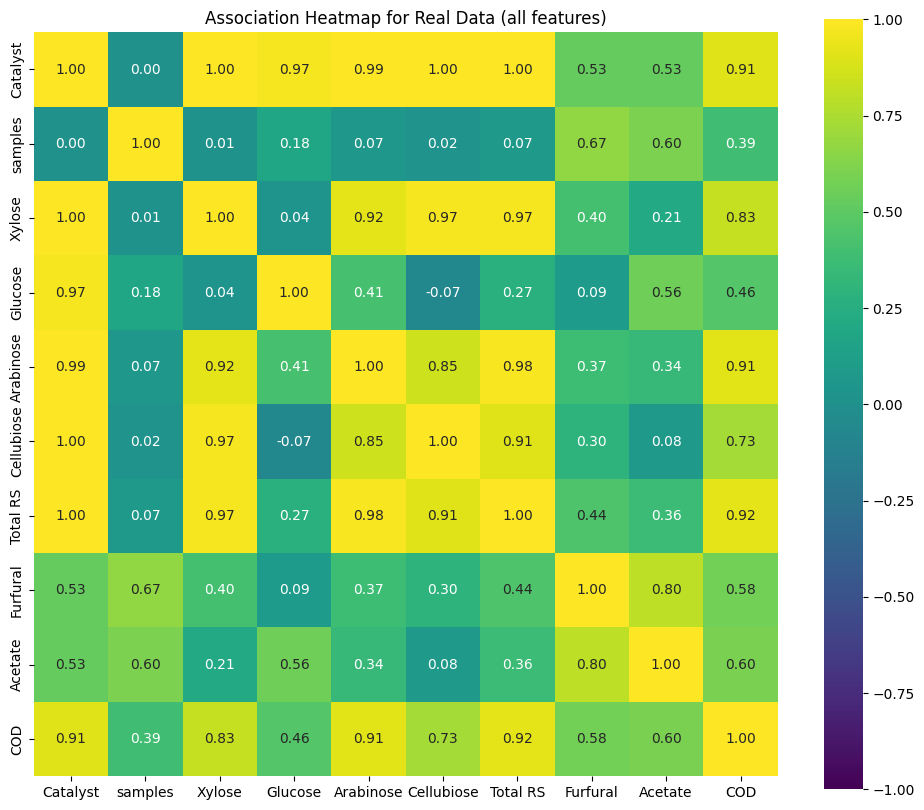

In [64]:
import matplotlib.pyplot as plt
import seaborn as sns
from dython.nominal import associations

# Get all columns except 'samples' since it's also categorical but not the focus here
# The 'associations' function will handle all types correctly.

print("Generating association heatmap for Real Data...")
plt.figure(figsize=(12, 10))
associations(
    real_data,
    ax=plt.gca(),
    cmap='viridis',
    cbar=True,
    annot=True,
    fmt='.2f',
    title='Association Heatmap for Real Data (all features)'
)
plt.show()

Generating association heatmap for Enforced Synthetic Data...


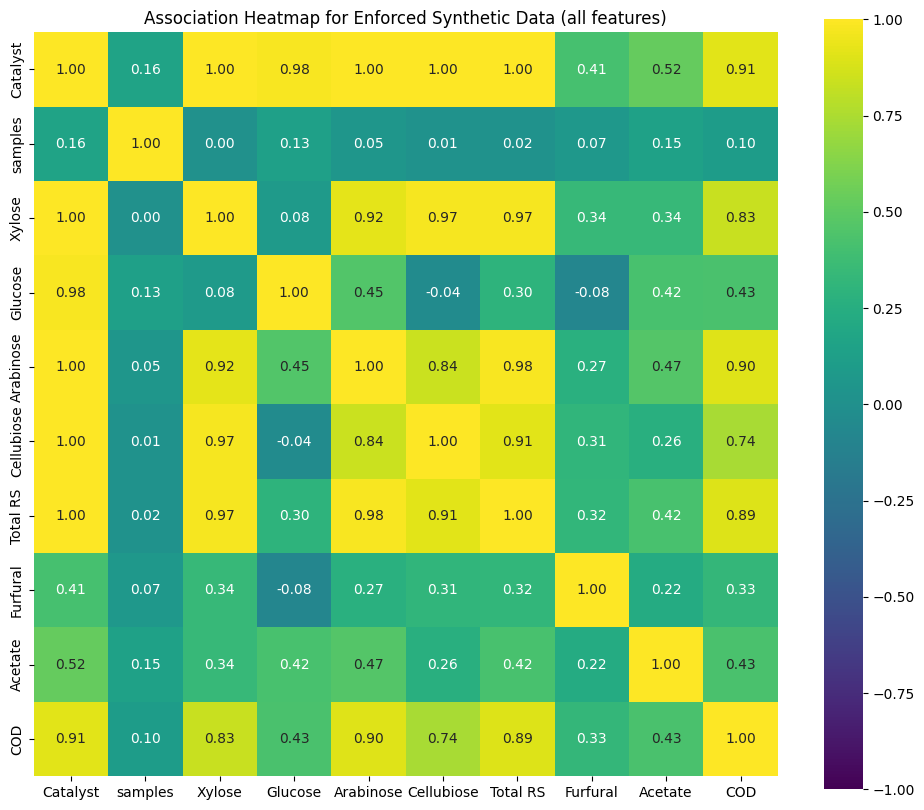

In [65]:
print("Generating association heatmap for Enforced Synthetic Data...")
plt.figure(figsize=(12, 10))
associations(
    synthetic_data_enforced,
    ax=plt.gca(),
    cmap='viridis',
    cbar=True,
    annot=True,
    fmt='.2f',
    title='Association Heatmap for Enforced Synthetic Data (all features)'
)
plt.show()

### Specific Correlations: 'Catalyst' with Other Features

To specifically address your request, let's visualize the correlations between the 'Catalyst' column and all other features for both the real and synthetic data. This will provide a focused view on how 'Catalyst' interactions are preserved in the synthetic dataset.

Generating 'Catalyst' correlation heatmap for Real Data...


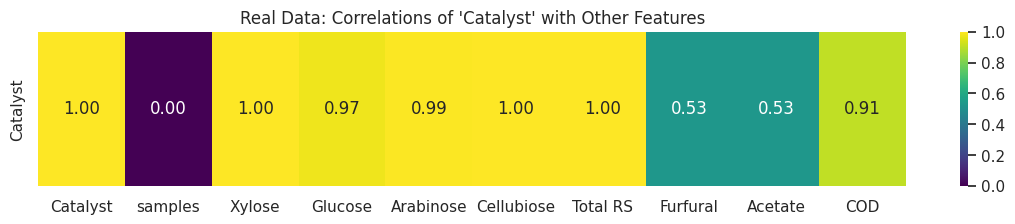

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
from dython.nominal import associations

print("Generating 'Catalyst' correlation heatmap for Real Data...")

# Calculate the full association matrix for real_data
real_corr_matrix = associations(real_data, nominal_columns=categorical_features, compute_only=True)["corr"]

# Extract the 'Catalyst' row (correlations of Catalyst with all other features)
catalyst_correlations_real = real_corr_matrix.loc[['Catalyst']]

plt.figure(figsize=(14, 2)) # Adjust size for better readability of a single row
sns.heatmap(
    catalyst_correlations_real,
    annot=True,
    cmap='viridis',
    fmt=".2f",
    cbar=True,
    yticklabels=True # Show 'Catalyst' label on y-axis
)
plt.title("Real Data: Correlations of 'Catalyst' with Other Features")
plt.show()

Generating 'Catalyst' correlation heatmap for Enforced Synthetic Data...


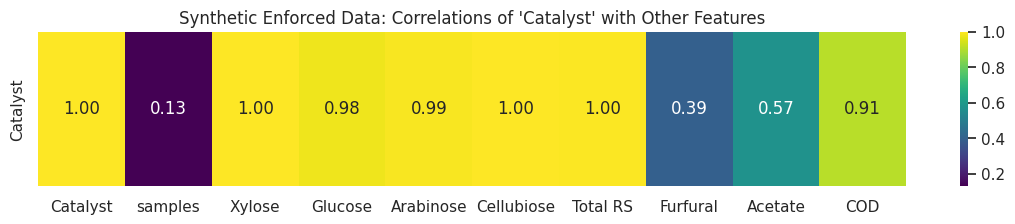

In [20]:
print("Generating 'Catalyst' correlation heatmap for Enforced Synthetic Data...")

# Calculate the full association matrix for synthetic_data_enforced
synthetic_corr_matrix = associations(synthetic_data_enforced, nominal_columns=categorical_features, compute_only=True)["corr"]

# Extract the 'Catalyst' row (correlations of Catalyst with all other features)
catalyst_correlations_synthetic = synthetic_corr_matrix.loc[['Catalyst']]

plt.figure(figsize=(14, 2)) # Adjust size for better readability of a single row
sns.heatmap(
    catalyst_correlations_synthetic,
    annot=True,
    cmap='viridis',
    fmt=".2f",
    cbar=True,
    yticklabels=True # Show 'Catalyst' label on y-axis
)
plt.title("Synthetic Enforced Data: Correlations of 'Catalyst' with Other Features")
plt.show()

To specifically inspect the 'Catalyst' correlations, you can look at the 'Catalyst' row and column in both heatmaps. The values represent various association metrics, depending on the data types of the paired columns.

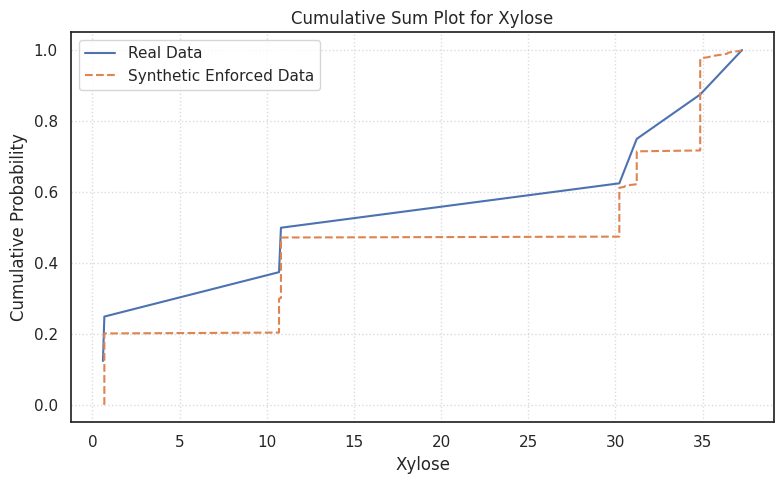

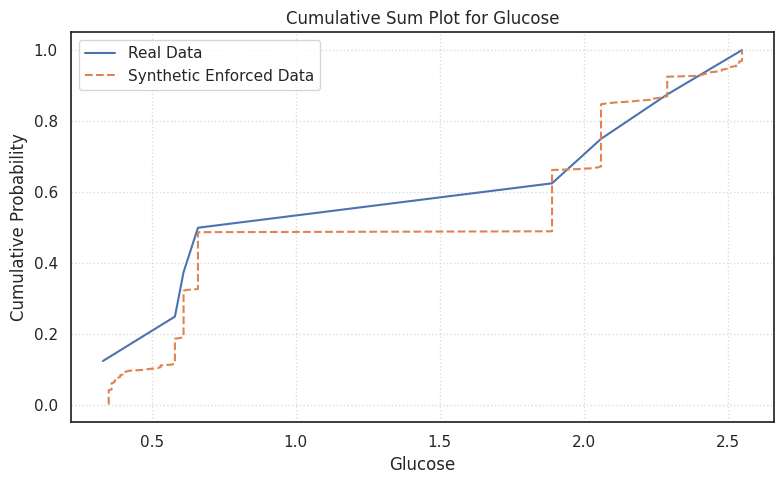

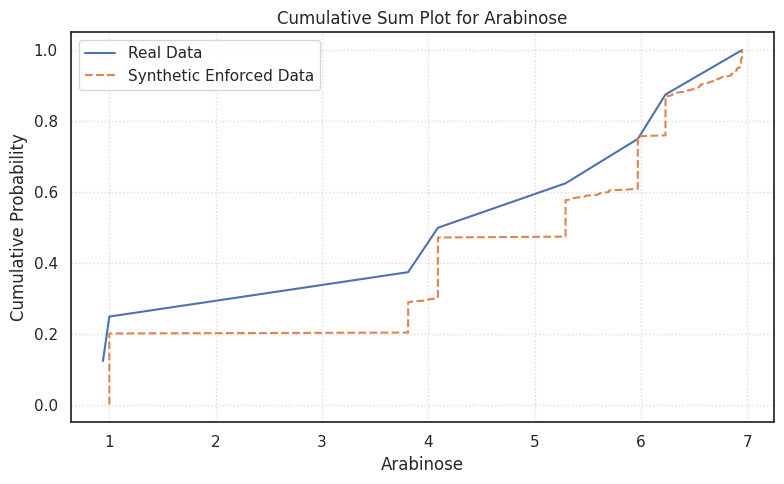

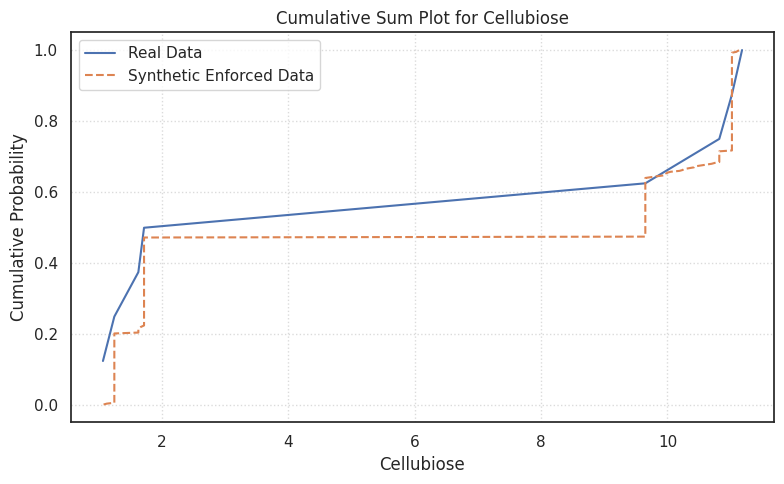

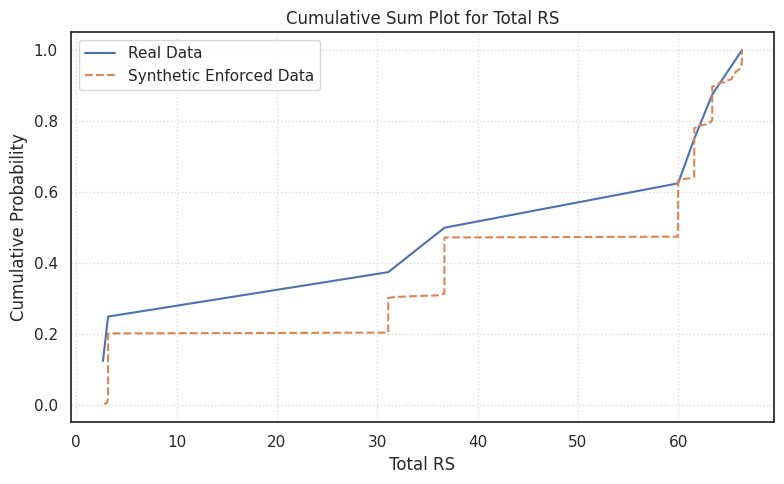

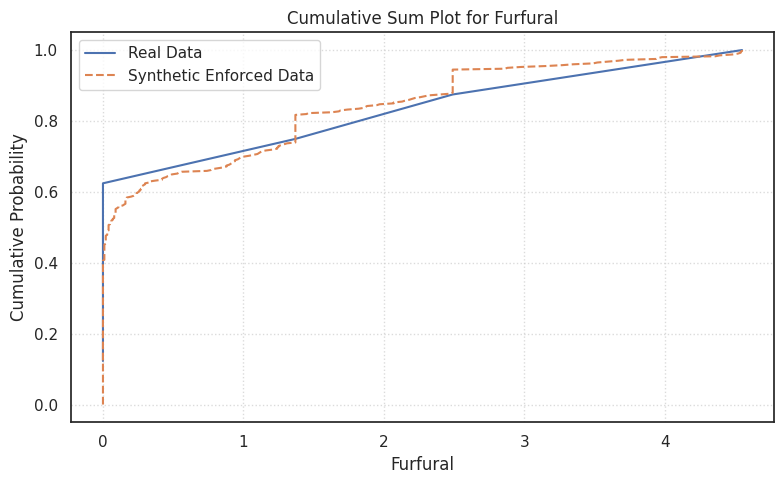

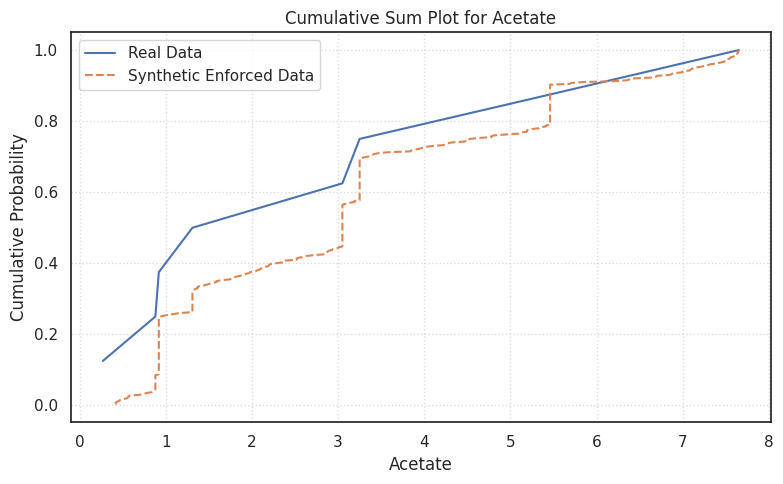

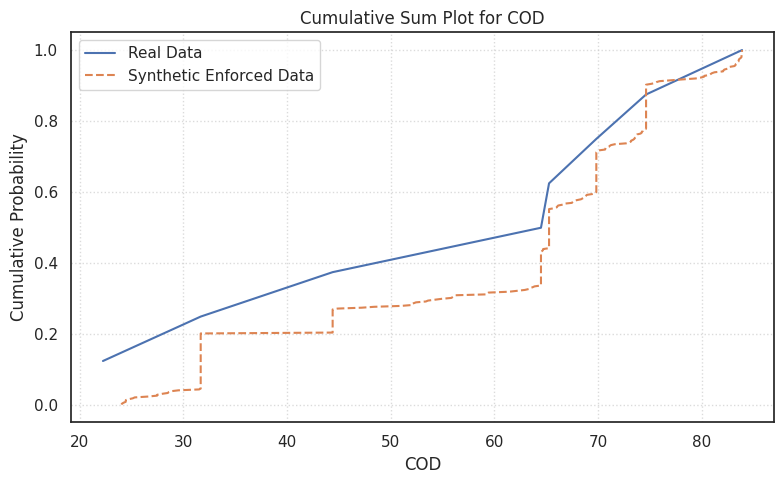

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

numerical_features = ['Xylose', 'Glucose', 'Arabinose', 'Cellubiose', 'Total RS', 'Furfural', 'Acetate', 'COD']

# Create cumulative sum plots for each numerical feature
for feature in numerical_features:
    plt.figure(figsize=(8, 5))

    # Sort and calculate cumulative sum for real_data
    real_sorted = np.sort(real_data[feature].dropna())
    real_cdf = np.arange(1, len(real_sorted) + 1) / len(real_sorted)
    plt.plot(real_sorted, real_cdf, label='Real Data', linestyle='-')

    # Sort and calculate cumulative sum for synthetic_data_enforced
    synthetic_sorted = np.sort(synthetic_data_enforced[feature].dropna())
    synthetic_cdf = np.arange(1, len(synthetic_sorted) + 1) / len(synthetic_sorted)
    plt.plot(synthetic_sorted, synthetic_cdf, label='Synthetic Enforced Data', linestyle='--')

    plt.title(f'Cumulative Sum Plot for {feature}')
    plt.xlabel(feature)
    plt.ylabel('Cumulative Probability')
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.tight_layout()
    plt.show()

### Kolmogorov-Smirnov (KS) Test for Distribution Comparison

The Kolmogorov-Smirnov (KS) test is a non-parametric test that compares the cumulative distribution functions (CDFs) of two samples. It quantifies the maximum difference between the CDFs of the two datasets. A smaller KS statistic and a higher p-value (typically greater than 0.05) suggest that the two samples are likely drawn from the same underlying distribution.

In [45]:
from scipy.stats import kstest

print("Kolmogorov-Smirnov (KS) Test Results:")
print("------------------------------------")

kstest_results = []

for feature in numerical_features:
    # Drop NA values to ensure the test runs correctly
    real_values = real_data[feature].dropna()
    synthetic_values = synthetic_data_enforced[feature].dropna()

    # Ensure there are enough values for the test
    if len(real_values) > 0 and len(synthetic_values) > 0:
        statistic, p_value = kstest(real_values, synthetic_values)
        kstest_results.append({'Feature': feature, 'KS Statistic': statistic, 'P-value': p_value})
    else:
        kstest_results.append({'Feature': feature, 'KS Statistic': 'N/A', 'P-value': 'N/A', 'Note': 'Insufficient data'})

kstest_df = pd.DataFrame(kstest_results)
display(kstest_df)

print("\nInterpretation: A smaller KS statistic and a higher p-value (e.g., > 0.05) indicate greater similarity between the distributions of the real and synthetic data for that feature.")

Kolmogorov-Smirnov (KS) Test Results:
------------------------------------


,Feature,KS Statistic,P-value
0,Xylose,0.1250,0.998130
1,Glucose,0.1250,0.998130
2,Arabinose,0.1250,0.998130
3,Cellubiose,0.1600,0.970278
4,Total RS,0.1250,0.998130
5,Furfural,0.2175,0.784322
6,Acetate,0.1800,0.926587
7,COD,0.1250,0.998130



Interpretation: A smaller KS statistic and a higher p-value (e.g., > 0.05) indicate greater similarity between the distributions of the real and synthetic data for that feature.


### Ranking Catalysts by 'Total RS' and 'Furfural' Production

To rank the catalysts based on 'Total RS' and 'Furfural' production, we'll calculate the average values of these features for each 'Catalyst' type in both the real and synthetic enforced datasets. Then, we will visualize these averages using heatmaps for easy comparison.

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate mean 'Total RS' and 'Furfural' for real_data grouped by 'Catalyst'
real_catalyst_ranking = real_data.groupby('Catalyst')[['Total RS', 'Furfural']].mean().sort_values(by='Total RS', ascending=False)

print("Real Data: Average 'Total RS' and 'Furfural' per Catalyst (Ranked by Total RS)")
display(real_catalyst_ranking)

# Calculate mean 'Total RS' and 'Furfural' for synthetic_data_enforced grouped by 'Catalyst'
synthetic_catalyst_ranking = synthetic_data_enforced.groupby('Catalyst')[['Total RS', 'Furfural']].mean().sort_values(by='Total RS', ascending=False)

print("\nSynthetic Enforced Data: Average 'Total RS' and 'Furfural' per Catalyst (Ranked by Total RS)")
display(synthetic_catalyst_ranking)


Real Data: Average 'Total RS' and 'Furfural' per Catalyst (Ranked by Total RS)


,Total RS,Furfural
Catalyst,,
HCl,63.185,2.275
HNO3,62.500,0.685
H2SO4,33.900,1.245
H2O,2.915,0.000



Synthetic Enforced Data: Average 'Total RS' and 'Furfural' per Catalyst (Ranked by Total RS)


,Total RS,Furfural
Catalyst,,
HNO3,62.346186,0.542474
HCl,62.222018,1.178596
H2SO4,34.546852,0.955556
H2O,3.158395,0.000000


### Heatmap Visualization of Catalyst Rankings

These heatmaps visually compare the average 'Total RS' and 'Furfural' values for each catalyst in both the real and synthetic datasets. This allows us to quickly assess how well the synthetic data preserves these key relationships.

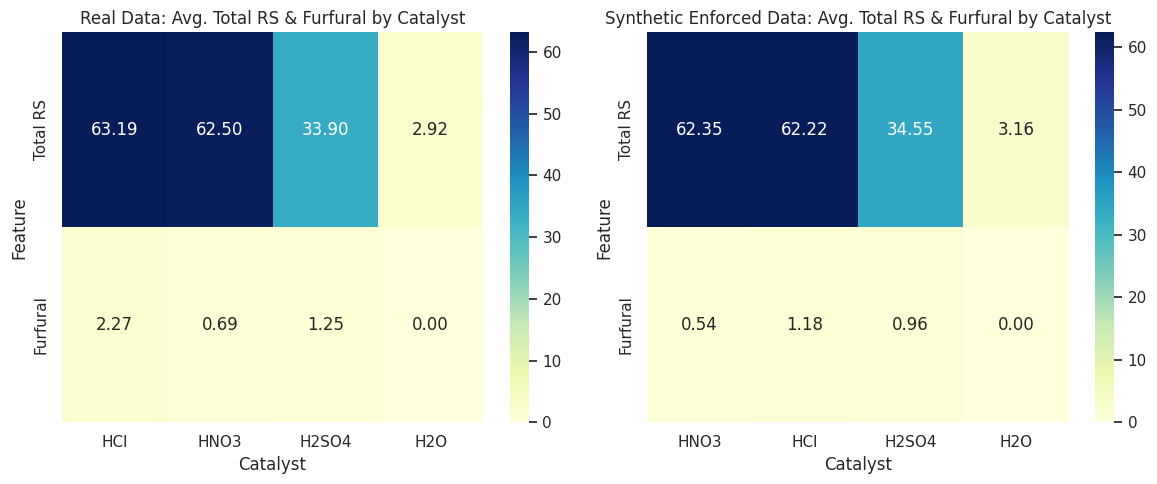

In [32]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.heatmap(real_catalyst_ranking.T, annot=True, cmap='YlGnBu', fmt=".2f")
plt.title('Real Data: Avg. Total RS & Furfural by Catalyst')
plt.xlabel('Catalyst')
plt.ylabel('Feature')

plt.subplot(1, 2, 2)
sns.heatmap(synthetic_catalyst_ranking.T, annot=True, cmap='YlGnBu', fmt=".2f")
plt.title('Synthetic Enforced Data: Avg. Total RS & Furfural by Catalyst')
plt.xlabel('Catalyst')
plt.ylabel('Feature')

plt.tight_layout()
plt.show()


### Exporting Synthetic Data to CSV

This cell exports the `synthetic_data_enforced` DataFrame to a CSV file named `synthetic_data_enforced.csv`. The `index=False` argument ensures that the DataFrame index is not written as a column in the CSV file.

In [44]:
synthetic_data_enforced.to_csv('synthetic_data_enforced.csv', index=False)
print("synthetic_data_enforced exported to 'synthetic_data_enforced.csv'")

synthetic_data_enforced exported to 'synthetic_data_enforced.csv'


## 2.6 Saving and Loading
We can save the synthesizer to share with others and sample more synthetic data in the future.

In [39]:
synthesizer.save('synthetic_data_enforced.pkl')

In [43]:
from sdv.utils import load_synthesizer

synthesizer = load_synthesizer('synthetic_data_enforced.pkl')
newly_sampled_synthetic_data = synthesizer.sample(num_rows=400)
# If you intended to sample from the existing DataFrame, use:
# newly_sampled_synthetic_data = synthetic_data_enforced.sample(n=400)